In [1]:
import uproot
import numpy as np

_orig_vstack = np.__dict__.get('_orig_vstack', np.vstack)  # Save original if not saved already
def _patched_vstack(arrays, dtype=None):
    stacked = _orig_vstack(arrays)
    return stacked.astype(dtype) if dtype is not None else stacked

np.vstack = _patched_vstack

import CLUEstering as clue
import pandas as pd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from HGCALEventClusterer_2D import HGCALEventClusterer_2D


In [10]:
data_low = uproot.open("100_e_20_80.root")
data_mid = uproot.open("100_e_80_140.root")
data_high = uproot.open("100_e_140_200.root")

In [13]:
tree1 = data_low['HGCALTBout;1']
x_t_low = tree1["hit_x"].array()
y_t_low = tree1["hit_y"].array()
z_t_low = tree1["hit_z"].array()
e_t_low = tree1["hit_Edep"].array()
layer_id_low = tree1['hit_layer'].array()
shower_id_low = tree1["hit_showerid"].array()

tree2 = data_mid['HGCALTBout;1']
x_t_mid = tree2["hit_x"].array()
y_t_mid = tree2["hit_y"].array()
z_t_mid = tree2["hit_z"].array()
e_t_mid = tree2["hit_Edep"].array()
layer_id_mid = tree2['hit_layer'].array()
shower_id_mid = tree2["hit_showerid"].array()

tree3 = data_high['HGCALTBout;1']
x_t_high = tree3["hit_x"].array()
y_t_high = tree3["hit_y"].array()
z_t_high = tree3["hit_z"].array()
e_t_high = tree3["hit_Edep"].array()
layer_id_high = tree3['hit_layer'].array()
shower_id_high = tree3["hit_showerid"].array()


In [22]:

clusterer = HGCALEventClusterer_2D(dc=1.3, rhoc=0.015, dm=2.6, pPB=10, backend="cpu serial")
seps_l = []
puritys_l = []
for i in range(len(x_t_low)):
    x = np.array(x_t_low[i])
    y = np.array(y_t_low[i])
    z = np.array(z_t_low[i])
    e = np.array(e_t_low[i])
    layers = np.array(layer_id_low[i])
    sids = np.array(shower_id_low[i])
    
    clusterer.read_event(x, y, z, e, layers, sids=sids)
    clusterer.cluster_event(verbose=False)
    
    sep = clusterer.get_shower_barycenter_separation(weight_by_energy=False)
    pur = clusterer.return_avg_purity()
    
    seps_l.append(sep)
    puritys_l.append(pur)
    
seps_m = []
puritys_m = []
for i in range(len(x_t_mid)):
    x = np.array(x_t_mid[i])
    y = np.array(y_t_mid[i])
    z = np.array(z_t_mid[i])
    e = np.array(e_t_mid[i])
    layers = np.array(layer_id_mid[i])
    sids = np.array(shower_id_mid[i])
    
    clusterer.read_event(x, y, z, e, layers, sids=sids)
    clusterer.cluster_event(verbose=False)
    
    sep = clusterer.get_shower_barycenter_separation(weight_by_energy=False)
    pur = clusterer.return_avg_purity()
    
    seps_m.append(sep)
    puritys_m.append(pur)

seps_h = []
puritys_h = []
for i in range(len(x_t_high)):
    x = np.array(x_t_high[i])
    y = np.array(y_t_high[i])
    z = np.array(z_t_high[i])
    e = np.array(e_t_high[i])
    layers = np.array(layer_id_high[i])
    sids = np.array(shower_id_high[i])
    
    clusterer.read_event(x, y, z, e, layers, sids=sids)
    clusterer.cluster_event(verbose=False)
    
    sep = clusterer.get_shower_barycenter_separation(weight_by_energy=False)
    pur = clusterer.return_avg_purity()
    
    seps_h.append(sep)
    puritys_h.append(pur)
 

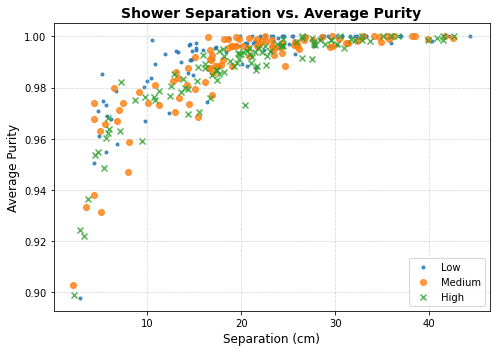

In [23]:
plt.figure(figsize=(7,5))

plt.scatter(seps_l, puritys_l, label="Low", marker=".", alpha=0.8)
plt.scatter(seps_m, puritys_m, label="Medium", marker="o", alpha=0.8)
plt.scatter(seps_h, puritys_h, label="High", marker="x", alpha=0.8)

plt.xlabel("Separation (cm)", fontsize=12)
plt.ylabel("Average Purity", fontsize=12)
plt.title("Shower Separation vs. Average Purity", fontsize=14, weight="bold")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


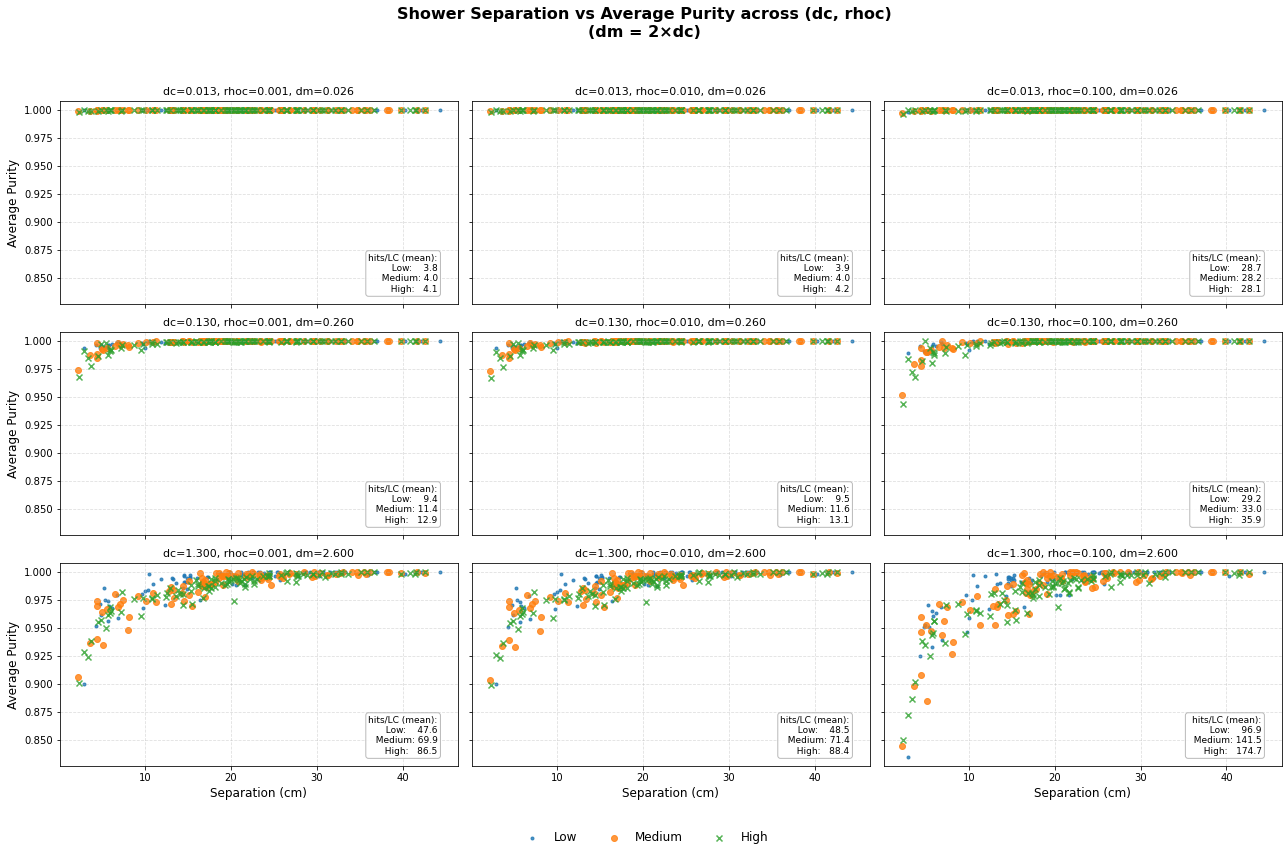

In [44]:
# --- parameter grids ---
dc_vals   = [0.013, 0.13, 1.3]      # rows
rhoc_vals = [0.001, 0.01, 0.1]           # cols

# --- helpers ---
def run_bin_once(x_t, y_t, z_t, e_t, layers_t, sids_t, dc, rhoc, dm):
    seps, purs, hits_per_LC = [], [], []
    clusterer = HGCALEventClusterer_2D(dc=dc, rhoc=rhoc, dm=dm, pPB=10, backend="cpu serial")
    for i in range(len(x_t)):
        x = np.asarray(x_t[i]); y = np.asarray(y_t[i]); z = np.asarray(z_t[i])
        e = np.asarray(e_t[i]); L = np.asarray(layers_t[i]); sids = np.asarray(sids_t[i])

        clusterer.read_event(x, y, z, e, L, sids=sids)
        clusterer.cluster_event(verbose=False)
        df = clusterer.get_cluster_summary()

        seps.append(clusterer.get_shower_barycenter_separation(weight_by_energy=False))
        purs.append(clusterer.return_avg_purity())
        hits_per_LC.append((len(x) / len(df)) if len(df) > 0 else np.nan)
    return np.array(seps), np.array(purs), np.array(hits_per_LC)

def run_all_bins(dc, rhoc, dm):
    l = run_bin_once(x_t_low,  y_t_low,  z_t_low,  e_t_low,  layer_id_low,  shower_id_low,  dc, rhoc, dm)
    m = run_bin_once(x_t_mid,  y_t_mid,  z_t_mid,  e_t_mid,  layer_id_mid,  shower_id_mid,  dc, rhoc, dm)
    h = run_bin_once(x_t_high, y_t_high, z_t_high, e_t_high, layer_id_high, shower_id_high, dc, rhoc, dm)
    return l, m, h  # each is (seps, purity, hits_per_LC)

# --- plotting grid sized to params ---
nrows, ncols = len(dc_vals), len(rhoc_vals)
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharex=True, sharey=True)
if nrows*ncols == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = np.array([axes])
elif ncols == 1:
    axes = axes.reshape(nrows, 1)

fig.suptitle("Shower Separation vs Average Purity across (dc, rhoc)\n(dm = 2×dc)", fontsize=16, fontweight="bold")

for r, dc in enumerate(dc_vals):
    for c, rhoc in enumerate(rhoc_vals):
        dm = 2.0 * dc
        ax = axes[r, c]
        (sl, pl, hl), (sm, pm, hm), (sh, ph, hh) = run_all_bins(dc, rhoc, dm)

        ax.scatter(sl, pl, label="Low",    marker=".", alpha=0.8)
        ax.scatter(sm, pm, label="Medium", marker="o", alpha=0.8)
        ax.scatter(sh, ph, label="High",   marker="x", alpha=0.8)

        ax.set_title(f"dc={dc:.3f}, rhoc={rhoc:.3f}, dm={dm:.3f}", fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.4)


        # annotate hits/LC as before
        text = (
            f"hits/LC (mean):\n"
            f"  Low:    {np.nanmean(hl):.1f}\n"
            f"  Medium: {np.nanmean(hm):.1f}\n"
            f"  High:   {np.nanmean(hh):.1f}"
        )
        ax.text(0.95, 0.05, text, transform=ax.transAxes,
                va="bottom", ha="right", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.9))


# axis labels on outer edges
for ax in axes[-1, :]:
    ax.set_xlabel("Separation (cm)", fontsize=12)
for ax in axes[:, 0]:
    ax.set_ylabel("Average Purity", fontsize=12)

# one shared legend (from first populated axis)
handles, labels = first_ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig("plots.pdf")
plt.show()
